# Part 1 : Spectral Bias and the F-principle

In this notebook, you will study how a neural network learns different frequency components of a 1D signal during training.
The objective is not only to fit a target function, but also to analyze the learning dynamics in a precise way: at different epochs, you will compare the prediction with the exact signal and you will measure the error on several prescribed Fourier modes.
The whole notebook is organized as a single guided lab. You must code the neural network and the training loop yourself, then use both visual and quantitative diagnostics to discuss the F-principle.

In [245]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

np.random.seed(0)
torch.manual_seed(0)


## 1. Dataset: a multi-frequency 1D signal

We construct a synthetic target function defined on $[0,1)$ as a superposition of three sine waves:

$$f(x) = 1.0 \sin(2\pi x) + 0.5 \sin(8\pi x) + 0.2 \sin(32\pi x)$$

As a consequence, $f$ has three frequency components:
- A **low frequency** ($k=1$), with amplitude $1.0$, wavelength $\approx 1.0$
- A **medium frequency** ($k=4$), with amplitude $0.5$, wavelength $\approx 0.25$
- A **high frequency** ($k=16$), with amplitude $0.2$, wavelength $\approx 0.0625$

This setting is simple enough to remain fully controlled, but rich enough to compare the behavior of the network on several scales.
In particular, the TP will combine two complementary viewpoints: the signal in physical space $x \mapsto f(x)$, and the modal coefficients associated with the three prescribed frequencies.


In [246]:
# --- Create the 1D dataset ---
N = 1024
x = np.linspace(0, 1, N, endpoint=False, dtype=np.float32)
x_t = torch.tensor(x, dtype=torch.float32).unsqueeze(1)

modes = np.array([1, 4, 16], dtype=np.float32)
amplitudes = np.array([1.0, 0.5, 0.2], dtype=np.float32)

components = [
    amplitude * np.sin(2.0 * np.pi * k * x)
    for amplitude, k in zip(amplitudes, modes)
]

f_true = np.sum(components, axis=0).astype(np.float32)
y_t = torch.tensor(f_true, dtype=torch.float32).unsqueeze(1)

def project_on_modes(values, x_grid, modes):
    values = np.asarray(values, dtype=np.float32)
    if values.ndim == 1:
        values = values[None, :]
    basis = np.stack([np.sin(2.0 * np.pi * k * x_grid) for k in modes], axis=1).astype(np.float32)
    return (2.0 / len(x_grid)) * values @ basis

true_modal_coeffs = project_on_modes(f_true, x, modes)[0]
print("Target modal coefficients:", dict(zip([int(k) for k in modes], true_modal_coeffs)))


Target modal coefficients: {1: 1.0, 4: 0.5000002, 16: 0.2}


## 2. Before training: inspect the target

Before running any optimization, look at the signal and its decomposition into modes.
Make a prediction: which mode do you expect the network to learn first, and which one should be the hardest?


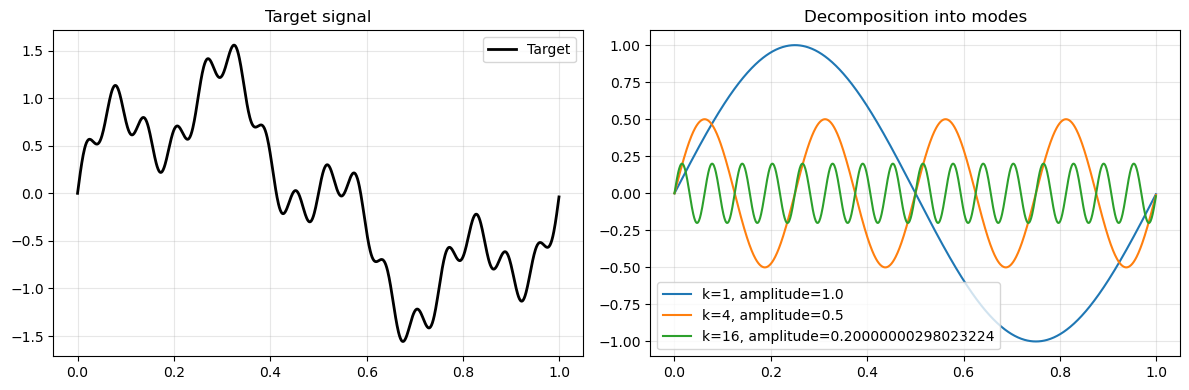

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(x, f_true, color="black", linewidth=2, label="Target")
axes[0].set_title("Target signal")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for component, k, amplitude in zip(components, modes, amplitudes):
    axes[1].plot(x, component, label=f"k={int(k)}, amplitude={amplitude}")
axes[1].set_title("Decomposition into modes")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## 3. Neural network model

We use a small fully connected network with scalar input and scalar output.
Complete the architecture below. The expected model is:

`Linear(1, 64) -> Tanh -> Linear(64, 64) -> Tanh -> Linear(64, 1)`


In [248]:
class Network(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        return self.net(x)


## 4. Optimization setup

We train the network with Adam and MSE loss.
To make the learning dynamics visible, we store predictions at selected epochs and we also track the error on each modal coefficient.


In [249]:
model = Network()
optimizer = optim.Adam(model.parameters(), lr=1e-2)
loss_fn = nn.MSELoss()
# TODO:: choose the Adam optimizer with lr = 1e-2 and the MSE loss function
#raise NotImplementedError("Complete optimizer and loss function.")


epochs = 4000
record_epochs = [1, 10, 50, 200, 1000, 4000]
analysis_every = 25

outputs = {}
history = {
    "epoch": [],
    "loss": [],
    "mode_errors": [],
    "pred_coeffs": [],
}

def modal_error(pred_values):
    pred_coeffs = project_on_modes(pred_values, x, modes)[0]
    return np.abs(pred_coeffs - true_modal_coeffs), pred_coeffs


## 5. Training loop

Complete the standard PyTorch training loop below.
In addition to the optimization step, the loop must:
- store the prediction at the epochs listed in `record_epochs`,
- compute the modal error regularly,
- record the training loss and the modal diagnostics in `history`.


In [250]:
for ep in range(1, epochs + 1):
    optimizer.zero_grad()
    output = model(x_t)
    loss = loss_fn(output, y_t)
    loss.backward()
    optimizer.step()
    # TODO: complete one optimization step
    # 1. reset the gradients
    # 2. compute the prediction
    # 3. compute the loss
    # 4. backpropagate
    # 5. update the parameters
    #raise NotImplementedError("Complete the training loop before running this cell.")

    if ep % analysis_every == 0 or ep in record_epochs or ep == epochs:
        with torch.no_grad():
            y_pred = model(x_t).cpu().numpy().squeeze()

        if ep in record_epochs:
            outputs[ep] = y_pred.copy()

        mode_errors, pred_coeffs = modal_error(y_pred)
        history["epoch"].append(ep)
        history["loss"].append(loss.item())
        history["mode_errors"].append(mode_errors)
        history["pred_coeffs"].append(pred_coeffs)

        rounded_errors = np.round(mode_errors, 4)
        print(
            f"epoch {ep:4d} | loss {loss.item():.3e} | "
            f"modal abs error {dict(zip([int(k) for k in modes], rounded_errors))}"
        )


epoch    1 | loss 7.046e-01 | modal abs error {1: 0.841, 4: 0.4611, 16: 0.1903}
epoch   10 | loss 3.064e-01 | modal abs error {1: 0.2097, 4: 0.3148, 16: 0.1539}
epoch   25 | loss 2.410e-01 | modal abs error {1: 0.1419, 4: 0.3104, 16: 0.1528}
epoch   50 | loss 2.064e-01 | modal abs error {1: 0.1996, 4: 0.344, 16: 0.1612}
epoch   75 | loss 1.528e-01 | modal abs error {1: 0.1001, 4: 0.3785, 16: 0.1694}
epoch  100 | loss 1.284e-01 | modal abs error {1: 0.0065, 4: 0.4277, 16: 0.18}
epoch  125 | loss 1.255e-01 | modal abs error {1: 0.0184, 4: 0.4196, 16: 0.1792}
epoch  150 | loss 1.228e-01 | modal abs error {1: 0.0044, 4: 0.4234, 16: 0.181}
epoch  175 | loss 1.184e-01 | modal abs error {1: 0.0027, 4: 0.4199, 16: 0.182}
epoch  200 | loss 1.085e-01 | modal abs error {1: 0.0117, 4: 0.4024, 16: 0.1827}
epoch  225 | loss 8.933e-02 | modal abs error {1: 0.0184, 4: 0.3548, 16: 0.1824}
epoch  250 | loss 6.611e-02 | modal abs error {1: 0.0178, 4: 0.2751, 16: 0.181}
epoch  275 | loss 5.295e-02 | modal

## 6. Visualization: predictions across epochs

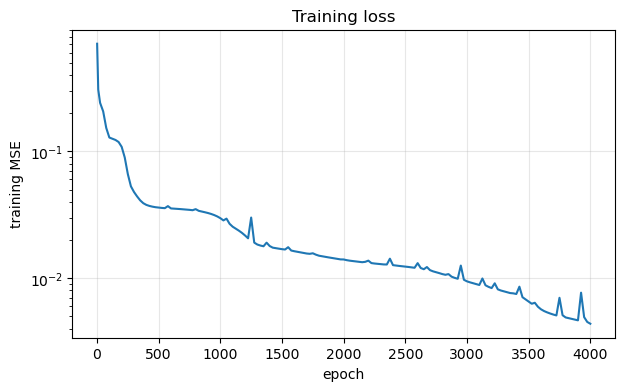

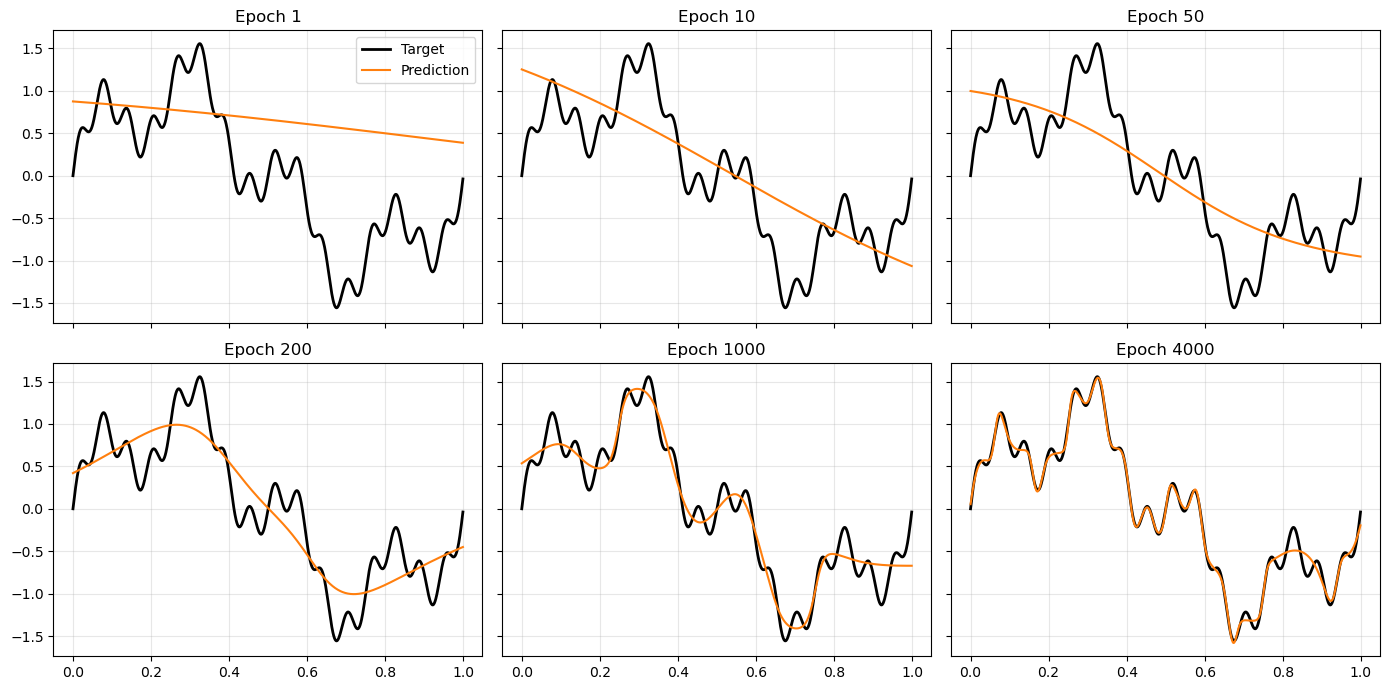

In [251]:
lab_epochs = np.array(history["epoch"])
lab_mode_errors = np.stack(history["mode_errors"])

plt.figure(figsize=(7, 4))
plt.semilogy(lab_epochs, history["loss"])
plt.xlabel("epoch")
plt.ylabel("training MSE")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, ep in zip(axes.flat, record_epochs):
    ax.plot(x, f_true, color="black", linewidth=2, label="Target")
    ax.plot(x, outputs[ep], color="C1", label="Prediction")
    ax.set_title(f"Epoch {ep}")
    ax.grid(True, alpha=0.3)
axes[0, 0].legend()
plt.tight_layout()
plt.show()


## 7. Modal diagnostics



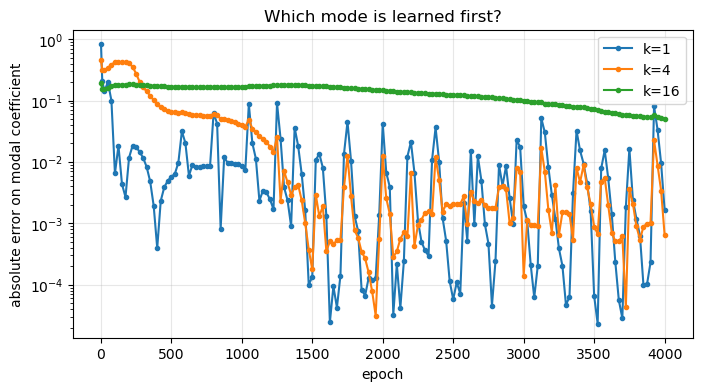

k= 1 | true=+1.0000 | pred=+0.9983 | abs error=1.6548e-03
k= 4 | true=+0.5000 | pred=+0.5006 | abs error=6.4617e-04
k=16 | true=+0.2000 | pred=+0.1491 | abs error=5.0868e-02
k=1 first goes below 5.00e-02 at epoch 100.
k=4 first goes below 5.00e-02 at epoch 900.
k=16 never goes below 5.00e-02.


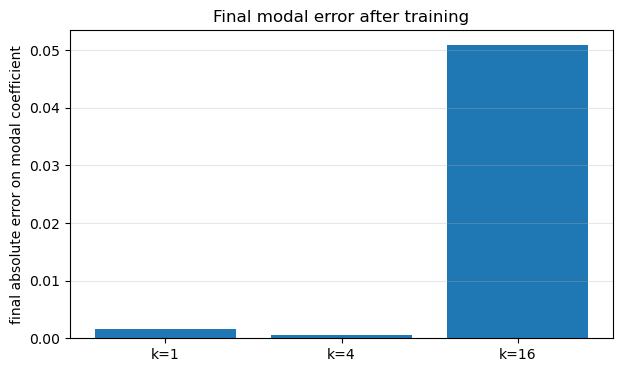

In [252]:
plt.figure(figsize=(8, 4))
for j, k in enumerate(modes):
    plt.semilogy(lab_epochs, lab_mode_errors[:, j], marker="o", markersize=3, label=f"k={int(k)}")
plt.xlabel("epoch")
plt.ylabel("absolute error on modal coefficient")
plt.title("Which mode is learned first?")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

final_pred_coeffs = np.array(history["pred_coeffs"][-1])
final_abs_error = np.abs(final_pred_coeffs - true_modal_coeffs)

for k, true_c, pred_c, err in zip(modes.astype(int), true_modal_coeffs, final_pred_coeffs, final_abs_error):
    print(f"k={k:2d} | true={true_c:+.4f} | pred={pred_c:+.4f} | abs error={err:.4e}")

threshold = 5e-2
for j, k in enumerate(modes.astype(int)):
    hits = np.where(lab_mode_errors[:, j] < threshold)[0]
    if len(hits) == 0:
        print(f"k={k} never goes below {threshold:.2e}.")
    else:
        print(f"k={k} first goes below {threshold:.2e} at epoch {int(lab_epochs[hits[0]])}.")

plt.figure(figsize=(7, 4))
plt.bar([f"k={int(k)}" for k in modes], final_abs_error)
plt.ylabel("final absolute error on modal coefficient")
plt.title("Final modal error after training")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


## 8. Guided questions

1. Before training, which mode did you expect to be learned first? Was your prediction correct?
2. On the snapshot figure, what is already captured at epochs 1, 10, 50, 200, 1000, and 4000?
3. Which mode reaches a small modal error first? Which one remains difficult for the longest time?
4. Change the target amplitudes to $[0.2,0.5,1.0]$, rerun the notebook, and explain what changed in the order of learning.

### Answer
1. I expected the k=1 mode to be learned first because it was the mode with the lower frequencies. So my prediction was right.
2. What is captured is the prediction of u with the f and A computed at those epochs.
3. The first one to reach small modal error ist the k=1 mode because it is the mode with the lowest frequency and the one wich reamin difficult is the mode k=16 because it is the most oscillatory one whith the highest frequency.
4. The order is not modify because it depends on the frequency and not on the amplitude. However the final modal errorafter trainning significantly explodes for mode k=1 and drop for k=16.


# Part 2: An inverse Poisson problem with random Fourier coefficients

In this second part, we still consider the one-dimensional Poisson equation on $\Omega=(0,1)$ with homogeneous Dirichlet boundary conditions:

$$-u''(x) = f(x), \qquad u(0)=u(1)=0.$$

We now work with a controlled family of forcing terms built from a fixed number of sine modes. At the beginning of the experiment, we choose an integer $K_{\max}$. For each sample of the dataset, we draw random coefficients

$$a_1, a_2, \ldots, a_{K_{\max}} \in [0,1],$$

and define the forcing term by

$$f(x) = \sum_{k=1}^{K_{\max}} a_k\sin(2\pi kx).$$

Since each basis function $\sin(2\pi kx)$ vanishes at $x=0$ and $x=1$, the associated exact solution is

$$u(x) = \sum_{k=1}^{K_{\max}} \frac{a_k}{(2\pi k)^2}\sin(2\pi kx).$$

As in the previous version, we do not learn the forward map $F \mapsto U$. Instead, we learn the inverse map

$$\mathcal{G}_\theta : U \longmapsto F.$$

The interest of this construction is that every sample contains several frequencies with random amplitudes. This makes it possible to study the inverse surrogate not only through global losses, but also through the reconstruction error of each mode.


x_grid shape       : (100,)
mode_ids           : [1 2 3 4 5 6 7 8]
coefficients shape : (1500, 8)
u_data shape       : (1500, 100)
f_data shape       : (1500, 100)


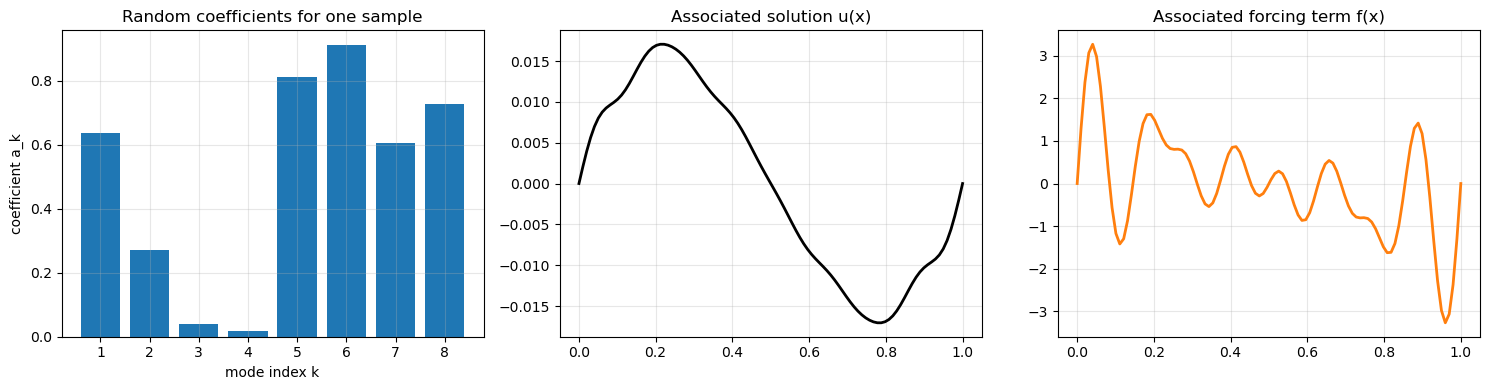

In [253]:
def build_inverse_poisson_dataset(N=100, n_samples=1500, K_max=8, seed=0):
    rng = np.random.default_rng(seed)
    x_grid = np.linspace(0.0, 1.0, N, dtype=np.float32)
    mode_ids = np.arange(1, K_max + 1, dtype=np.float32)

    sine_basis = np.sin(2.0 * np.pi * mode_ids[:, None] * x_grid[None, :]).astype(np.float32)
    coefficients = rng.uniform(0.0, 1.0, size=(n_samples, K_max)).astype(np.float32)

    scales = (2.0 * np.pi * mode_ids) ** 2
    f_data = coefficients @ sine_basis
    u_data = (coefficients / scales[None, :]) @ sine_basis
    basis_pinv = np.linalg.pinv(sine_basis).astype(np.float32)

    return {
        'x_grid': x_grid,
        'mode_ids': mode_ids,
        'coefficients': coefficients,
        'sine_basis': sine_basis,
        'basis_pinv': basis_pinv,
        'u_data': u_data.astype(np.float32),
        'f_data': f_data.astype(np.float32),
    }


inverse_dataset = build_inverse_poisson_dataset(N=100, n_samples=1500, K_max=8, seed=0)
x_grid = inverse_dataset['x_grid']
mode_ids = inverse_dataset['mode_ids']
coefficients = inverse_dataset['coefficients']

print('x_grid shape       :', inverse_dataset['x_grid'].shape)
print('mode_ids           :', mode_ids.astype(int))
print('coefficients shape :', inverse_dataset['coefficients'].shape)
print('u_data shape       :', inverse_dataset['u_data'].shape)
print('f_data shape       :', inverse_dataset['f_data'].shape)

sample_idx = 0
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(mode_ids.astype(int), coefficients[sample_idx], color='C0')
axes[0].set_xlabel('mode index k')
axes[0].set_ylabel('coefficient a_k')
axes[0].set_title('Random coefficients for one sample')
axes[0].grid(True, alpha=0.3)

axes[1].plot(x_grid, inverse_dataset['u_data'][sample_idx], color='black', linewidth=2)
axes[1].set_title('Associated solution u(x)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(x_grid, inverse_dataset['f_data'][sample_idx], color='C1', linewidth=2)
axes[2].set_title('Associated forcing term f(x)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Train/test split

Each sample is generated independently by drawing a new vector of random coefficients $(a_1, \ldots, a_{K_{\max}})$. A standard random train/test split is therefore enough to mimic the usual surrogate-learning setting: the model is trained on one collection of inverse-problem samples and evaluated on unseen ones.

The training set is used to optimize the parameters of the surrogate, while the test set is kept aside to measure its generalization ability.


In [254]:
train_ratio = 0.8
n_samples = len(coefficients)
n_train = int(train_ratio * n_samples)

permutation = np.random.permutation(n_samples)
train_idx = permutation[:n_train]
test_idx = permutation[n_train:]

coeff_train = coefficients[train_idx]
coeff_test = coefficients[test_idx]
u_train = inverse_dataset['u_data'][train_idx]
f_train = inverse_dataset['f_data'][train_idx]
u_test = inverse_dataset['u_data'][test_idx]
f_test = inverse_dataset['f_data'][test_idx]

print('number of training samples :', len(train_idx))
print('number of test samples     :', len(test_idx))
print('coeff_train shape          :', coeff_train.shape)
print('coeff_test shape           :', coeff_test.shape)
print('u_train shape              :', u_train.shape)
print('f_train shape              :', f_train.shape)
print('u_test shape               :', u_test.shape)
print('f_test shape               :', f_test.shape)


number of training samples : 1200
number of test samples     : 300
coeff_train shape          : (1200, 8)
coeff_test shape           : (300, 8)
u_train shape              : (1200, 100)
f_train shape              : (1200, 100)
u_test shape               : (300, 100)
f_test shape               : (300, 100)


## Build And Train The Inverse Surrogate

In this section, you must complete the neural network model and the training procedure yourself.

More precisely, your tasks are:

1. define the architecture of the inverse surrogate $U \mapsto F$;
2. choose the loss function used during training;
3. write the training loop and the test evaluation step.

Once these TODOs are completed, the last cell of this part will automatically display the training curves and the evolution of the predicted forcing term and modal coefficients across epochs.


In [255]:
def mean_relative_l2(prediction, target, eps=1e-12):
    numerator = np.sum((prediction - target) ** 2, axis=1)
    denominator = np.sum(target ** 2, axis=1) + eps
    return np.mean(np.sqrt(numerator / denominator))


def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].semilogy(history['epoch'], history['train_mse'], label='train')
    axes[0].semilogy(history['epoch'], history['test_mse'], label='test')
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('MSE loss')
    axes[0].set_title('Inverse surrogate training curves')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].semilogy(history['epoch'], history['test_rel_l2'], color='C2')
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('mean relative L2 error')
    axes[1].set_title('Test relative error')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_snapshot_diagnostics(x_grid, mode_ids, exact_forcing, exact_coefficients, snapshots, snapshot_epochs, basis_pinv):
    fig, axes = plt.subplots(2, len(snapshot_epochs), figsize=(3 * len(snapshot_epochs), 6), squeeze=False)

    for col, ep in enumerate(snapshot_epochs):
        predicted_forcing = snapshots[ep]
        predicted_coefficients = predicted_forcing @ basis_pinv

        axes[0, col].plot(x_grid, exact_forcing, color='black', linewidth=2, label='Exact forcing')
        axes[0, col].plot(x_grid, predicted_forcing, color='C1', label='Prediction')
        axes[0, col].set_title(f'Epoch {ep}')
        axes[0, col].grid(True, alpha=0.3)

        axes[1, col].bar(mode_ids - 0.15, exact_coefficients, width=0.3, color='black', label='Exact coefficients')
        axes[1, col].bar(mode_ids + 0.15, predicted_coefficients, width=0.3, color='C1', label='Predicted coefficients')
        axes[1, col].set_xlabel('mode index k')
        axes[1, col].grid(True, alpha=0.3)

    axes[0, 0].set_ylabel('forcing value')
    axes[1, 0].set_ylabel('coefficient value')
    axes[0, 0].legend()
    axes[1, 0].legend()
    plt.tight_layout()
    plt.show()


u_train_t = torch.tensor(u_train, dtype=torch.float32)
f_train_t = torch.tensor(f_train, dtype=torch.float32)
u_test_t = torch.tensor(u_test, dtype=torch.float32)
f_test_t = torch.tensor(f_test, dtype=torch.float32)


class InversePoissonSurrogate(nn.Module):
    def __init__(self, N, hidden=128, bottleneck=24):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(N, hidden),
            nn.ReLU(),
            nn.Linear(hidden, bottleneck),
            nn.ReLU(),
            nn.Linear(bottleneck, hidden),
            nn.ReLU(),
            nn.Linear(hidden, N),
        )
        # TODO:
        # Build a neural network that maps R^N to R^N.
        # A good starting point is a small MLP with a bottleneck:
        # Linear(N, hidden) -> Tanh -> Linear(hidden, bottleneck) -> Tanh
        # -> Linear(bottleneck, hidden) -> Tanh -> Linear(hidden, N)
        #raise NotImplementedError('TODO: define the layers of the inverse surrogate.')

    def forward(self, inputs):
        return self.net(inputs)
        # TODO:
        # Apply the network to the input tensor `inputs`.
        #raise NotImplementedError('TODO: implement the forward pass.')
        

def train_inverse_surrogate(
    model,
    u_train_t,
    f_train_t,
    u_test_t,
    f_test_t,
    f_test_np,
    snapshot_epochs,
    snapshot_index,
    epochs=1500,
    lr=1e-1,
    record_every=25,
):
    history = {'epoch': [], 'train_mse': [], 'test_mse': [], 'test_rel_l2': []}
    snapshots = {}

    # TODO:
    # 1. Define an Adam optimizer for `model.parameters()`.
    # 2. Define the training loss.
    #    Hint: the reconstruction target is the forcing term, so a mean-squared error is a natural first choice.
    optimizer = optim.LBFGS(model.parameters(), lr)
    loss_fn = nn.MSELoss()
    #raise NotImplementedError('TODO: define the optimizer and loss function.')


    # TODO:
    # Complete the training loop.
    # At each epoch, you should:
    # - put the model in train mode,
    # - zero the gradients,
    # - compute the prediction on `u_train_t`,
    # - compute the training loss against `f_train_t`,
    # - backpropagate,
    # - update the parameters.
    for ep in range(1, epochs + 1):
        model.train()
        def closure():
            optimizer.zero_grad()
            pred_train = model(u_train_t)
            loss = loss_fn(pred_train, f_train_t)
            loss.backward()
            return loss
        optimizer.step(closure)
        #optimizer.step()
        #raise NotImplementedError('TODO: complete the training loop.')


        if ep % record_every == 0 or ep in snapshot_epochs:
            model.eval()
            with torch.no_grad():
                pred_test = model(u_test_t)
                pred_test_np = pred_test.cpu().numpy()

            test_mse = loss_fn(pred_test, f_test_t).item()
            test_rel_l2 = mean_relative_l2(pred_test_np, f_test_np)

            history['epoch'].append(ep)
            history['train_mse'].append(loss.item())
            history['test_mse'].append(test_mse)
            history['test_rel_l2'].append(test_rel_l2)

            if ep in snapshot_epochs:
                snapshots[ep] = pred_test_np[snapshot_index]


    return history, pred_test_np, snapshots



## Visual Diagnostics

After completing the TODOs above, run the next cell.
It will train your inverse surrogate, then display:

1. the training and test curves;
2. the predicted forcing term on one representative test sample at several epochs;
3. the corresponding predicted modal coefficients.

The selected sample is chosen so that the highest mode has a large amplitude, which makes the reconstruction of high frequencies easier to inspect visually.


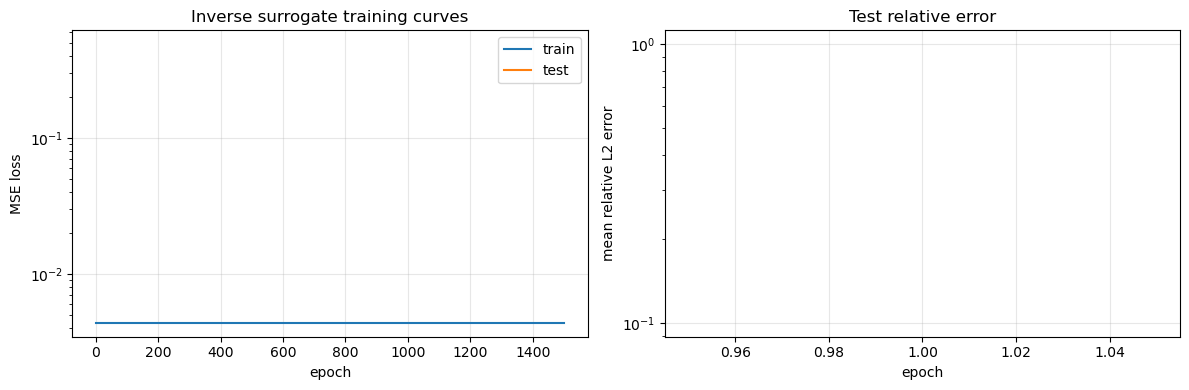

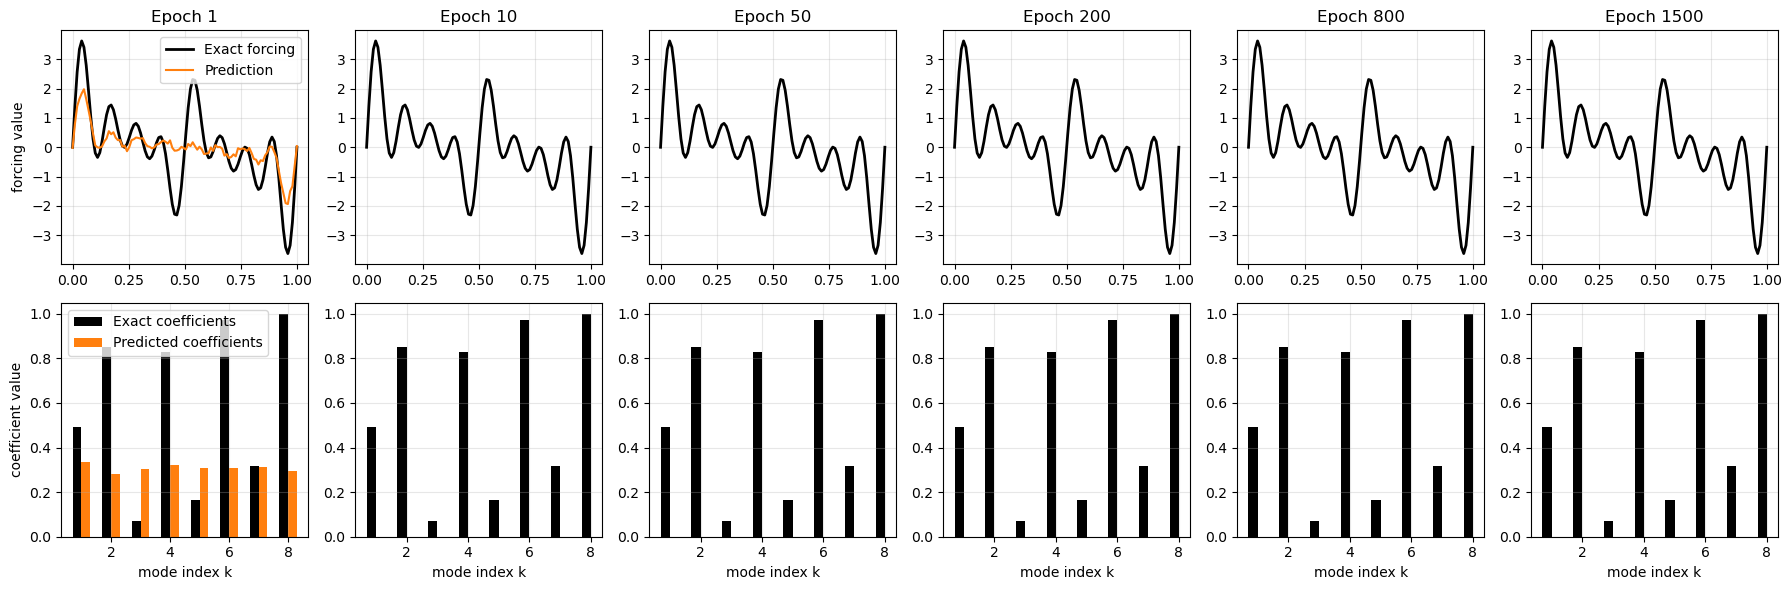

Final recorded train MSE    : 0.004376279655843973
Final recorded test MSE     : nan
Final recorded test rel. L2 : nan


In [256]:
basis_pinv = inverse_dataset['basis_pinv']
analysis_sample_idx = int(np.argmax(coeff_test[:, -1]))
snapshot_epochs = [1, 10, 50, 200, 800, 1500]

inverse_model = InversePoissonSurrogate(N=u_train.shape[1], hidden=128, bottleneck=24)

history, f_test_pred, snapshots = train_inverse_surrogate(
    model=inverse_model,
    u_train_t=u_train_t,
    f_train_t=f_train_t,
    u_test_t=u_test_t,
    f_test_t=f_test_t,
    f_test_np=f_test,
    snapshot_epochs=snapshot_epochs,
    snapshot_index=analysis_sample_idx,
    epochs=1500,
    lr=1e-3,
    record_every=25,
)

plot_training_curves(history)

plot_snapshot_diagnostics(
    x_grid=x_grid,
    mode_ids=mode_ids,
    exact_forcing=f_test[analysis_sample_idx],
    exact_coefficients=coeff_test[analysis_sample_idx],
    snapshots=snapshots,
    snapshot_epochs=snapshot_epochs,
    basis_pinv=basis_pinv,
)

print('Final recorded train MSE    :', history['train_mse'][-1])
print('Final recorded test MSE     :', history['test_mse'][-1])
print('Final recorded test rel. L2 :', history['test_rel_l2'][-1])


## Guided Questions For Part 2

1. Compare the train and test curves. Does the inverse surrogate generalize reasonably well to unseen samples?
2. On the forcing snapshots, which structures are reconstructed first during training?
3. On the coefficient bar plots, do the low-index modes become accurate before the high-index modes?
4. At a fixed epoch, which part of the signal is still missing when the prediction is not yet accurate?
5. Using the formula of the exact solution, explain why the inverse map $U \mapsto F$ is more sensitive to high modes than the forward map $F \mapsto U$.

### Answer

1. The train and test curve are pretty the same and it seems that there are no overfitting nor underfitting and this might be because the network architechture is really simple so very robust to under or over fitting

2. We first reconstruct oscillation and then the amplitude

3. Yes it is low index that became more accurate before high index

4. The Amplitude

5. ?????????????????????
